# Pandas: Groupby

`groupby` is an amazingly powerful function in pandas. But it is also complicated to use and understand.
The point of this lesson is to make you feel confident in using `groupby` and its cousins, `resample` and `rolling`. 

These notes are loosely based on the [Pandas GroupBy Documentation](http://pandas.pydata.org/pandas-docs/stable/groupby.html).

The "split/apply/combine" concept was first introduced in a paper by Hadley Wickham: <https://www.jstatsoft.org/article/view/v040i01>.


Imports:

In [1]:
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = (12,7)
%matplotlib inline
import pandas as pd

First we read the Earthquake data from our previous assignment:

In [2]:
df = pd.read_csv('https://dsrs.atmos.umd.edu/DATA/445Files/all_month.csv', parse_dates=['time'], index_col='id')
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
id,,,,,,,,,,,,,,,,,,,,,
ak2026dggvcr,2026-02-15 21:41:26.917000+00:00,60.802000,-150.700000,27.30,1.80,ml,29,80,0.20000,1.20,...,2026-02-15T21:43:30.628Z,"13 km S of Point Possession, Alaska",earthquake,3.30,1.8956,0.30,6.0,automatic,ak,ak
nc75314387,2026-02-15 21:23:14.890000+00:00,38.815834,-122.818832,1.04,1.01,md,5,126,0.01019,0.01,...,2026-02-15T21:24:53.179Z,"7 km NW of The Geysers, CA",earthquake,0.51,1.3200,0.53,8.0,automatic,nc,nc
nc75314377,2026-02-15 21:04:32.750000+00:00,38.813999,-122.816330,1.18,0.72,md,15,110,0.01058,0.03,...,2026-02-15T21:06:07.970Z,"7 km NW of The Geysers, CA",earthquake,0.25,0.5700,0.21,15.0,automatic,nc,nc
nc75314372,2026-02-15 21:04:10.020000+00:00,38.813667,-122.815834,1.27,2.53,md,44,50,0.01071,0.05,...,2026-02-15T21:07:39.210Z,"7 km NW of The Geysers, CA",earthquake,0.13,0.2000,0.18,49.0,automatic,nc,nc
us6000s9f6,2026-02-15 20:54:37.098000+00:00,-15.119600,-173.310200,10.00,5.30,mb,53,61,2.79500,0.68,...,2026-02-15T21:13:37.040Z,"106 km NNE of Hihifo, Tonga",earthquake,10.97,1.8680,0.03,373.0,reviewed,us,us


In [3]:
df = pd.read_csv('https://dsrs.atmos.umd.edu/DATA/445Files/all_month.csv', parse_dates=['time'], index_col='id')
df['country'] = df.place.str.split(', ').str[-1]
df_small = df[df.mag<4]
df = df[df.mag>4]
df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource,country
id,,,,,,,,,,,,,,,,,,,,,
us6000s9f6,2026-02-15 20:54:37.098000+00:00,-15.1196,-173.3102,10.000,5.3,mb,53,61,2.795,0.68,...,"106 km NNE of Hihifo, Tonga",earthquake,10.97,1.868,0.030,373.0,reviewed,us,us,Tonga
us6000s9ey,2026-02-15 18:28:44.061000+00:00,51.2620,-169.2440,10.000,4.3,mb,51,186,1.729,0.81,...,"188 km S of Nikolski, Alaska",earthquake,7.47,1.942,0.054,95.0,reviewed,us,us,Alaska
us6000s9ei,2026-02-15 15:58:48.801000+00:00,48.3271,154.5612,54.981,6.0,mww,60,76,5.372,0.65,...,"284 km SSW of Severo-Kuril’sk, Russia",earthquake,10.62,6.834,0.061,26.0,reviewed,us,us,Russia
us6000s9e5,2026-02-15 13:44:06.602000+00:00,-11.4831,117.9622,10.000,4.9,mb,54,63,2.645,0.50,...,"266 km SSW of Tambolaka, Indonesia",earthquake,7.99,1.829,0.086,43.0,reviewed,us,us,Indonesia
us6000s9e0,2026-02-15 12:46:02.903000+00:00,-2.7274,140.6332,10.000,4.4,mb,22,141,0.223,1.42,...,"14 km S of Abepura, Indonesia",earthquake,6.68,1.766,0.143,14.0,reviewed,us,us,Indonesia


## An Example

This is an example of a "one-liner" that you can accomplish with groupby.

<Axes: xlabel='country'>

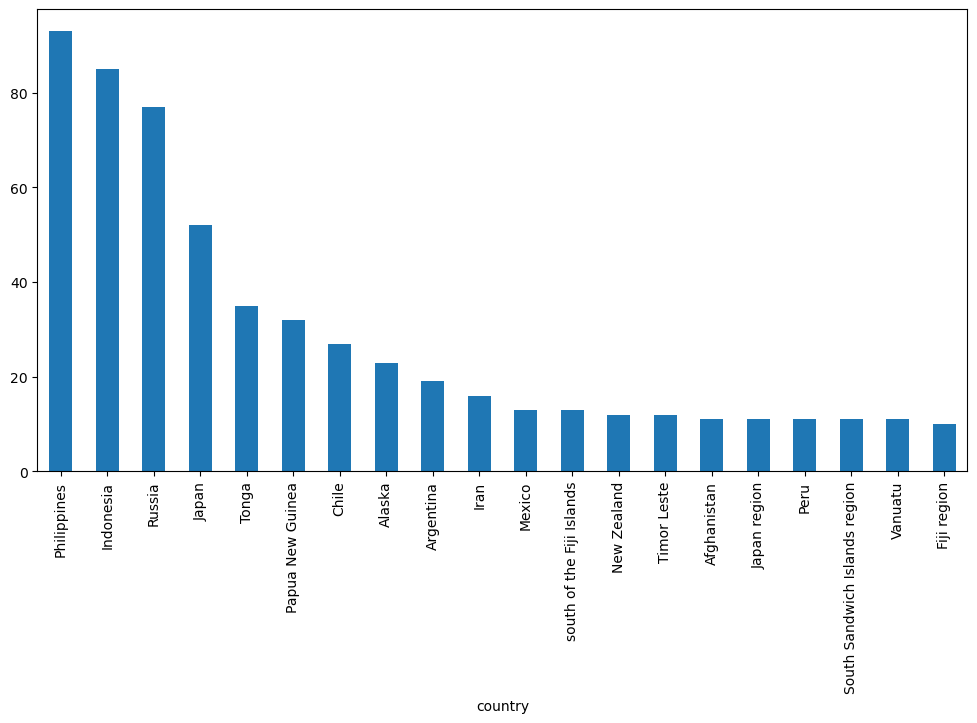

In [4]:
df.groupby('country').mag.count().nlargest(20).plot(kind='bar', figsize=(12,6))

<Axes: xlabel='country'>

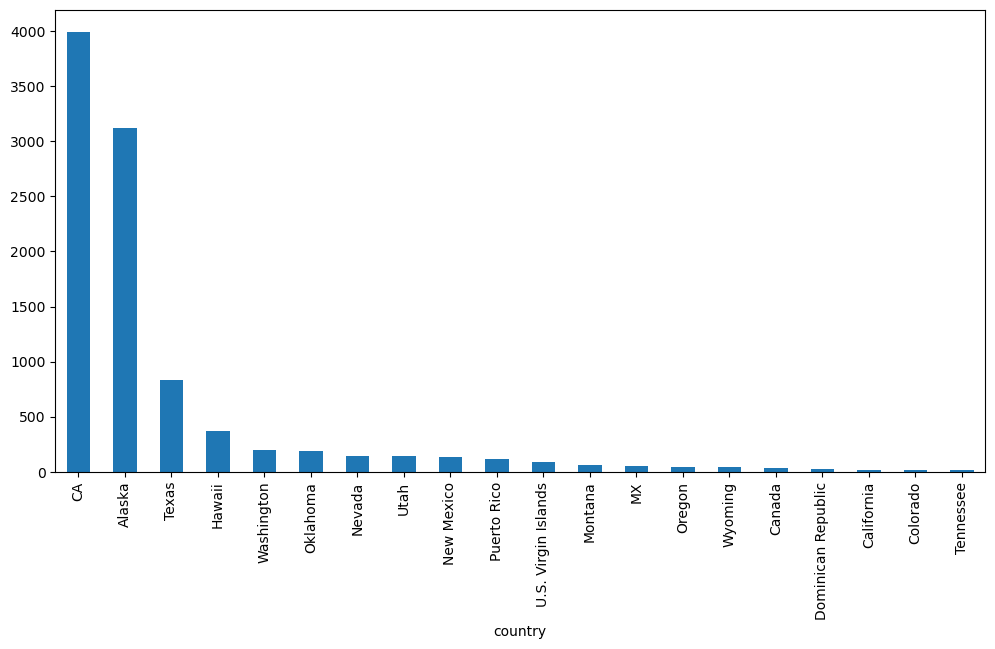

In [5]:
df_small.groupby('country').mag.count().nlargest(20).plot(kind='bar', figsize=(12,6))

## What Happened?

Let's break apart this operation a bit. The workflow with `groupby` can be divided into three general steps:

1. **Split**: Partition the data into different groups based on some criterion.
1. **Apply**: Do some caclulation within each group. Different types of "apply" steps might be
  1. *Aggregation*: Get the mean or max within the group.
  1. *Transformation*: Normalize all the values within a group
  1. *Filtration*: Eliminate some groups based on a criterion.
1. **Combine**: Put the results back together into a single object.

![split-apply-combine](https://miro.medium.com/max/1840/1*JbF6nhrQsn4f-TaSF6IR9g.png)

### The `groupby` method

Both `Series` and `DataFrame` objects have a groupby method. It accepts a variety of arguments, but the simplest way to think about it is that you pass another series, whose unique values are used to split the original object into different groups.

via <https://medium.com/analytics-vidhya/split-apply-combine-strategy-for-data-mining-4fd6e2a0cc99>

In [6]:
df.groupby(df.country)

There is a shortcut for doing this with dataframes: you just pass the column name:

In [7]:
df.groupby('country')

### The `GroubBy` object

When we call, `groupby` we get back a `GroupBy` object:

In [8]:
gb = df.groupby('country')
gb

The length tells us how many groups were found:

In [9]:
len(gb)

102

All of the groups are available as a dictionary via the `.groups` attribute:

In [10]:
groups = gb.groups
type(groups)

pandas.io.formats.printing.PrettyDict

In [13]:
list(groups.keys())
# list(groups.keys())[2]
# list(groups.values())[2]

Index(['us6000s6ha'], dtype='object', name='id')

### Iterating and selecting groups

You can loop through the groups if you want.

In [14]:
for key, group in gb: # DataFrameGroupBy object
    display(group.head())
    print(f'The key is "{key}"')
    break

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource,country
id,,,,,,,,,,,,,,,,,,,,,
us6000s99m,2026-02-14 22:58:11.144000+00:00,36.5038,70.2425,209.510,4.3,mb,44,158,2.181,1.03,...,"35 km ESE of Farkhār, Afghanistan",earthquake,8.00,7.964,0.109,24.0,reviewed,us,us,Afghanistan
us6000s8lg,2026-02-12 22:12:32.689000+00:00,36.5496,67.5055,10.000,4.5,mb,26,180,2.426,1.07,...,"23 km SW of Khulm, Afghanistan",earthquake,6.29,1.947,0.135,16.0,reviewed,us,us,Afghanistan
us6000s7ws,2026-02-11 20:10:57.733000+00:00,37.3063,69.8633,53.093,4.3,mb,45,100,2.307,0.92,...,"20 km N of Rustāq, Afghanistan",earthquake,6.28,9.741,0.106,25.0,reviewed,us,us,Afghanistan
us6000s7bt,2026-02-08 19:41:10.037000+00:00,36.5908,71.2556,108.429,4.2,mb,27,98,1.978,0.68,...,"26 km WSW of Ashkāsham, Afghanistan",earthquake,6.73,7.942,0.104,26.0,reviewed,us,us,Afghanistan
us6000s6q0,2026-02-05 18:09:49.141000+00:00,36.5095,70.0572,226.848,4.2,mb,25,122,2.128,0.89,...,"19 km ESE of Farkhār, Afghanistan",earthquake,5.34,7.923,0.158,12.0,reviewed,us,us,Afghanistan


The key is "Afghanistan"


And you can get a specific group by key.

In [15]:
gb.get_group('Chile').head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource,country
id,,,,,,,,,,,,,,,,,,,,,
us6000s9dj,2026-02-15 10:18:06.720000+00:00,-21.2187,-68.8818,120.268,4.6,mb,33,70,0.592,0.96,...,"65 km W of Ollagüe, Chile",earthquake,7.22,5.485,0.109,25.0,reviewed,us,us,Chile
us6000s9bv,2026-02-15 05:32:29.111000+00:00,-21.7787,-68.6576,131.589,4.3,mb,33,60,0.543,0.70,...,"74 km SW of Ollagüe, Chile",earthquake,6.32,5.294,0.109,24.0,reviewed,us,us,Chile
us6000s96v,2026-02-14 08:28:50.552000+00:00,-48.3605,-75.9978,17.223,4.7,mb,31,145,3.637,0.69,...,"284 km WSW of Cochrane, Chile",earthquake,9.97,5.063,0.082,45.0,reviewed,us,us,Chile
us6000s95u,2026-02-14 04:01:27.954000+00:00,-20.5653,-67.8937,167.276,4.4,mb,47,65,1.255,1.20,...,"82 km NNE of Ollagüe, Chile",earthquake,7.63,7.698,0.091,36.0,reviewed,us,us,Chile
us6000s8mh,2026-02-13 00:58:25.993000+00:00,-30.7444,-71.4924,39.453,4.3,mwr,42,59,0.142,1.11,...,"32 km WSW of Ovalle, Chile",earthquake,5.88,6.126,0.045,47.0,reviewed,us,us,Chile


## Aggregation

Now that we know how to create a `GroupBy` object, let's learn how to do aggregation on it.

One way us to use the `.aggregate` method, which accepts another function as its argument. The result is automatically combined into a new dataframe with the group key as the index.

In [16]:
import warnings
warnings.filterwarnings("ignore")

gb.aggregate(np.max).head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
country,,,,,,,,,,,,,,,,,,,,,
Afghanistan,2026-02-14 22:58:11.144000+00:00,37.3063,71.2556,226.848,4.5,mb,48,180,6.406,1.13,...,2026-02-15T03:27:49.040Z,"52 km S of Jurm, Afghanistan",earthquake,10.68,10.3640,0.158,63.0,reviewed,us,us
Alaska,2026-02-15 18:28:44.061000+00:00,63.1520,178.6020,155.186,5.3,mww,219,316,1.729,1.20,...,2026-02-15T21:35:48.346Z,"Rat Islands, Aleutian Islands, Alaska",earthquake,95.40,23.1933,0.400,605.0,reviewed,us,us
Albania,2026-02-04 18:50:28.494000+00:00,40.6760,20.9323,10.000,4.1,mb,33,85,1.051,0.86,...,2026-02-04T22:21:02.765Z,"7 km NW of Bilisht, Albania",earthquake,4.86,1.9780,0.370,2.0,reviewed,us,us
Antarctica,2026-02-04 00:30:29.918000+00:00,-67.5240,114.2836,10.000,4.9,mb,44,70,1.936,0.61,...,2026-02-04T02:52:23.040Z,Antarctica,earthquake,8.68,1.7690,0.091,38.0,reviewed,us,us
Argentina,2026-02-14 05:54:32.426000+00:00,-23.1068,-64.7447,246.886,4.9,mww,88,156,3.057,1.23,...,2026-02-15T21:15:27.040Z,"97 km W of San Antonio de los Cobres, Argentina",earthquake,13.11,17.0150,0.370,48.0,reviewed,us,us


By default, the operation is applied to every column. That's usually not what we want. We can use both `.` or `[]` syntax to select a specific column to operate on. Then we get back a series.

In [17]:
gb.mag.aggregate(np.max).head()

country
Afghanistan    4.5
Alaska         5.3
Albania        4.1
Antarctica     4.9
Argentina      4.9
Name: mag, dtype: float64

In [18]:
gb.mag.aggregate(np.max).nlargest(10)

country
Vanuatu                          6.4
Chile                            6.2
Fiji region                      6.2
Russia                           6.2
Japan region                     6.1
New Zealand                      6.1
New Caledonia                    6.0
South Sandwich Islands region    6.0
Indonesia                        5.9
Papua New Guinea                 5.9
Name: mag, dtype: float64

There are shortcuts for common aggregation functions:

In [19]:
gb.mag.max().nlargest(10)

country
Vanuatu                          6.4
Chile                            6.2
Fiji region                      6.2
Russia                           6.2
Japan region                     6.1
New Zealand                      6.1
New Caledonia                    6.0
South Sandwich Islands region    6.0
Indonesia                        5.9
Papua New Guinea                 5.9
Name: mag, dtype: float64

In [20]:
gb.mag.min().nsmallest(10)

country
Alaska       4.1
Albania      4.1
Argentina    4.1
Canada       4.1
Chile        4.1
Fiji         4.1
Greece       4.1
Indonesia    4.1
Iran         4.1
Japan        4.1
Name: mag, dtype: float64

In [21]:
gb.mag.mean().nlargest(10)

country
Cuba                                5.500000
Tristan da Cunha region             5.400000
southern East Pacific Rise          5.400000
west of Macquarie Island            5.350000
Samoa                               5.300000
Tanzania                            5.300000
Galapagos Triple Junction region    5.200000
Prince Edward Islands region        5.200000
southern Mid-Atlantic Ridge         5.166667
Ascension Island region             5.133333
Name: mag, dtype: float64

In [22]:
gb.mag.std().nlargest(10)

country
Pakistan                       0.690652
Iceland                        0.636396
Vanuatu                        0.620264
Burma (Myanmar)                0.573730
southern Mid-Atlantic Ridge    0.568624
Fiji region                    0.551866
Japan region                   0.529837
New Zealand                    0.500000
New Caledonia                  0.496208
west of Macquarie Island       0.494975
Name: mag, dtype: float64

We can also apply multiple functions at once:

In [23]:
gb.mag.aggregate([np.min, np.max, np.mean]).head()

,min,max,mean
country,,,
Afghanistan,4.2,4.5,4.309091
Alaska,4.1,5.3,4.504348
Albania,4.1,4.1,4.100000
Antarctica,4.9,4.9,4.900000
Argentina,4.1,4.9,4.415789


<Axes: xlabel='country'>

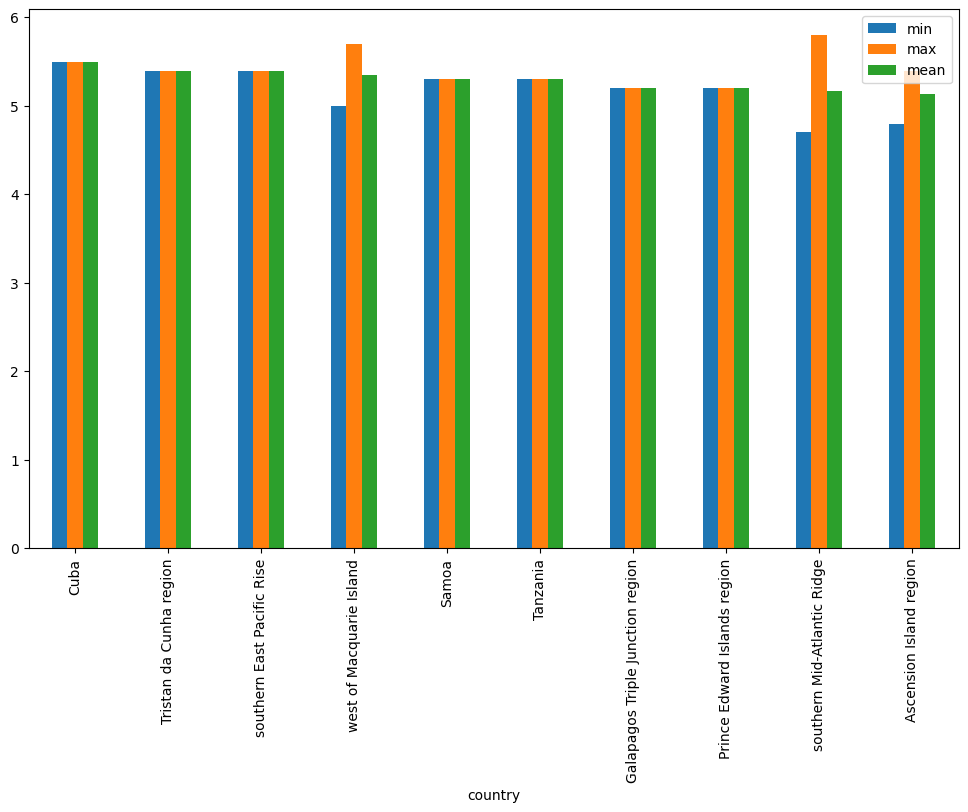

In [24]:
gb.mag.aggregate([np.min, np.max, np.mean]).nlargest(10, 'mean').plot(kind='bar')

## Transformation

The key difference between aggregation and transformation is that aggregation returns a *smaller* object than the original, indexed by the group keys, while *transformation* returns an object with the same index (and same size) as the original object. Groupby + transformation is used when applying an operation that requires information about the whole group.

In this example, we standardize the earthquakes in each country so that the distribution has zero mean and unit variance. We do this by first defining a function called `standardize` and then passing it to the `transform` method.

I admit that I don't know why you would want to do this. `transform` makes more sense to me in the context of time grouping operation. See below for another example.

In [25]:
def standardize(x):
    return (x - x.mean())/x.std()

mag_standardized_by_country = gb.mag.transform(standardize)
mag_standardized_by_country.head()

id
us6000s9f6    1.339582
us6000s9ey   -0.492364
us6000s9ei    3.159668
us6000s9e5    0.673125
us6000s9e0   -0.676300
Name: mag, dtype: float64

## Time Grouping

We already saw how pandas has a strong built-in understanding of time. This capability is even more powerful in the context of `groupby`. With datasets indexed by a pandas `DateTimeIndex`, we can easily group and resample the data using common time units.

To get started, let's load the timeseries data we already explored in past lessons.

In [26]:
import urllib
import pandas as pd

header_url = 'ftp://ftp.ncdc.noaa.gov/pub/data/uscrn/products/daily01/HEADERS.txt'
with urllib.request.urlopen(header_url) as response:
    data = response.read().decode('utf-8') # convert bytes to string objects
lines = data.split('\n')
headers = lines[1].split(' ') # split strings around given separator/delimiter

ftp_base = 'ftp://ftp.ncdc.noaa.gov/pub/data/uscrn/products/daily01/'
dframes = []
for year in range(2016, 2019):
    data_url = f'{year}/CRND0103-{year}-NY_Millbrook_3_W.txt'               
    df = pd.read_csv(ftp_base + data_url, parse_dates=[1],
                     names=headers, header=None, sep='\\s+', # names: sequence of column labels to apply
                     na_values=[-9999.0, -99.0])
    dframes.append(df)

df = pd.concat(dframes) # concatenate pandas objects along a particular axis (axis=0 by default)
df = df.set_index('LST_DATE')

In [27]:
headers
# dframes

['WBANNO',
 'LST_DATE',
 'CRX_VN',
 'LONGITUDE',
 'LATITUDE',
 'T_DAILY_MAX',
 'T_DAILY_MIN',
 'T_DAILY_MEAN',
 'T_DAILY_AVG',
 'P_DAILY_CALC',
 'SOLARAD_DAILY',
 'SUR_TEMP_DAILY_TYPE',
 'SUR_TEMP_DAILY_MAX',
 'SUR_TEMP_DAILY_MIN',
 'SUR_TEMP_DAILY_AVG',
 'RH_DAILY_MAX',
 'RH_DAILY_MIN',
 'RH_DAILY_AVG',
 'SOIL_MOISTURE_5_DAILY',
 'SOIL_MOISTURE_10_DAILY',
 'SOIL_MOISTURE_20_DAILY',
 'SOIL_MOISTURE_50_DAILY',
 'SOIL_MOISTURE_100_DAILY',
 'SOIL_TEMP_5_DAILY',
 'SOIL_TEMP_10_DAILY',
 'SOIL_TEMP_20_DAILY',
 'SOIL_TEMP_50_DAILY',
 'SOIL_TEMP_100_DAILY',
 '']

In [28]:
df.head()

,WBANNO,CRX_VN,LONGITUDE,LATITUDE,T_DAILY_MAX,T_DAILY_MIN,T_DAILY_MEAN,T_DAILY_AVG,P_DAILY_CALC,SOLARAD_DAILY,...,SOIL_MOISTURE_10_DAILY,SOIL_MOISTURE_20_DAILY,SOIL_MOISTURE_50_DAILY,SOIL_MOISTURE_100_DAILY,SOIL_TEMP_5_DAILY,SOIL_TEMP_10_DAILY,SOIL_TEMP_20_DAILY,SOIL_TEMP_50_DAILY,SOIL_TEMP_100_DAILY,
LST_DATE,,,,,,,,,,,,,,,,,,,,,
2016-01-01,64756,2.422,-73.74,41.79,3.4,-0.5,1.5,1.3,0.0,1.69,...,0.233,0.204,0.155,0.147,4.2,4.4,5.1,6.0,7.6,NaN
2016-01-02,64756,2.422,-73.74,41.79,2.9,-3.6,-0.4,-0.3,0.0,6.25,...,0.227,0.199,0.152,0.144,2.8,3.1,4.2,5.7,7.4,NaN
2016-01-03,64756,2.422,-73.74,41.79,5.1,-1.8,1.6,1.1,0.0,5.69,...,0.223,0.196,0.151,0.141,2.6,2.8,3.8,5.2,7.2,NaN
2016-01-04,64756,2.422,-73.74,41.79,0.5,-14.4,-6.9,-7.5,0.0,9.17,...,0.220,0.194,0.148,0.139,1.7,2.1,3.4,4.9,6.9,NaN
2016-01-05,64756,2.422,-73.74,41.79,-5.2,-15.5,-10.3,-11.7,0.0,9.34,...,0.213,0.191,0.148,0.138,0.4,0.9,2.4,4.3,6.6,NaN


This timeseries has daily resolution, and the daily plots are somewhat noisy.

<Axes: xlabel='LST_DATE'>

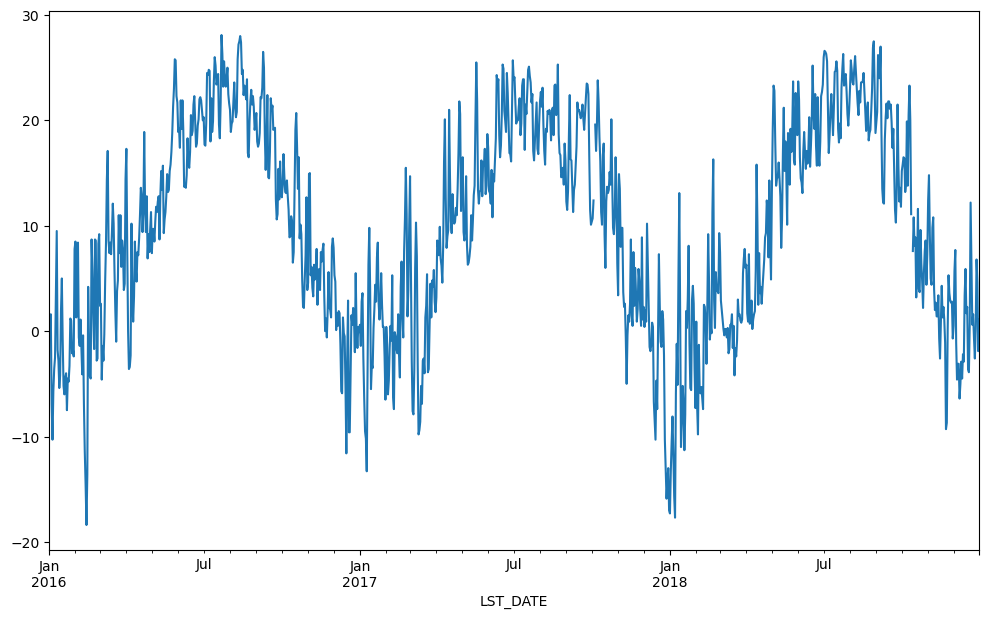

In [29]:
df.T_DAILY_MEAN.plot()

A common way to analyze such data in climate science is to create a "climatology," which contains the average values in each month or day of the year. We can do this easily with groupby. Recall that `df.index` is a pandas `DateTimeIndex` object.

In [30]:
monthly_climatology = df.groupby(df.index.month).mean(numeric_only=True) 
# numeric_only=True is needed as some variables are not numeric (e.g. SUR_TEMP_DAILY_TYPE)
monthly_climatology

,WBANNO,CRX_VN,LONGITUDE,LATITUDE,T_DAILY_MAX,T_DAILY_MIN,T_DAILY_MEAN,T_DAILY_AVG,P_DAILY_CALC,SOLARAD_DAILY,...,SOIL_MOISTURE_10_DAILY,SOIL_MOISTURE_20_DAILY,SOIL_MOISTURE_50_DAILY,SOIL_MOISTURE_100_DAILY,SOIL_TEMP_5_DAILY,SOIL_TEMP_10_DAILY,SOIL_TEMP_20_DAILY,SOIL_TEMP_50_DAILY,SOIL_TEMP_100_DAILY,
LST_DATE,,,,,,,,,,,,,,,,,,,,,
1,64756.0,2.488667,-73.74,41.79,2.924731,-7.122581,-2.100000,-1.905376,2.478495,5.812258,...,0.240250,0.200698,0.153645,0.160859,0.150538,0.248387,0.788172,1.766667,3.364516,NaN
2,64756.0,2.487882,-73.74,41.79,6.431765,-5.015294,0.712941,1.022353,4.077647,8.495882,...,0.247714,0.210044,0.159153,0.163889,1.216471,1.169412,1.278824,1.617647,2.442353,NaN
3,64756.0,2.488667,-73.74,41.79,7.953763,-3.035484,2.455914,2.643011,2.788172,13.211290,...,0.228612,0.203634,0.157796,0.160366,3.450538,3.400000,3.372043,3.480645,3.777419,NaN
4,64756.0,2.488667,-73.74,41.79,14.793333,1.816667,8.302222,8.574444,2.396667,15.295889,...,0.214067,0.195844,0.153878,0.158100,9.415556,9.117778,8.455556,7.618889,6.670000,NaN
5,64756.0,2.488667,-73.74,41.79,21.235484,8.460215,14.850538,15.121505,3.015054,17.288602,...,0.204796,0.187097,0.148871,0.155720,16.934409,16.640860,15.612903,14.208602,12.455914,NaN
6,64756.0,2.488667,-73.74,41.79,25.627778,11.837778,18.733333,19.026667,3.053333,21.913333,...,0.136911,0.135211,0.129422,0.152711,22.403333,22.126667,20.956667,19.448889,17.552222,NaN
7,64756.0,2.488667,-73.74,41.79,28.568817,15.536559,22.054839,22.012903,3.865591,21.570645,...,0.105806,0.095204,0.114419,0.150000,25.448387,25.318280,24.163441,22.746237,21.068817,NaN
8,64756.0,2.488667,-73.74,41.79,27.473118,15.351613,21.410753,21.378495,4.480645,18.493333,...,0.156161,0.132333,0.128796,0.158750,24.758065,24.829032,24.116129,23.325806,22.301075,NaN
9,64756.0,2.488667,-73.74,41.79,24.084444,12.032222,18.057778,17.866667,3.730000,13.625667,...,0.136900,0.126422,0.121356,0.154000,21.028889,21.168889,20.921111,20.834444,20.707778,NaN


Each row in this new dataframe respresents the average values for the months (1=January, 2=February, etc.)

We can apply more customized aggregations, as with any groupby operation. Below we keep the mean of the mean, max of the max, and min of the min for the temperature measurements.

In [31]:
monthly_T_climatology = df.groupby(df.index.month).aggregate({'T_DAILY_MEAN': 'mean',
                                                              'T_DAILY_MAX': 'max',
                                                              'T_DAILY_MIN': 'min'})
monthly_T_climatology.head()

,T_DAILY_MEAN,T_DAILY_MAX,T_DAILY_MIN
LST_DATE,,,
1,-2.100000,16.9,-26.0
2,0.712941,24.9,-24.7
3,2.455914,26.8,-16.5
4,8.302222,30.6,-11.3
5,14.850538,33.4,-1.6


<Axes: xlabel='LST_DATE'>

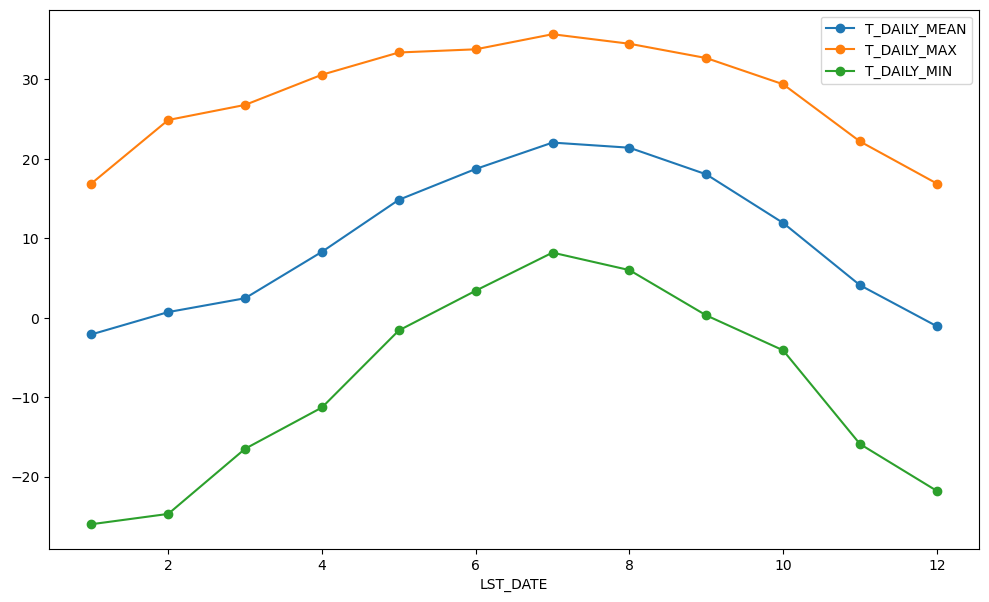

In [32]:
monthly_T_climatology.plot(marker='o')

If we want to do it on a finer scale, we can group by day of year.

<Axes: xlabel='LST_DATE'>

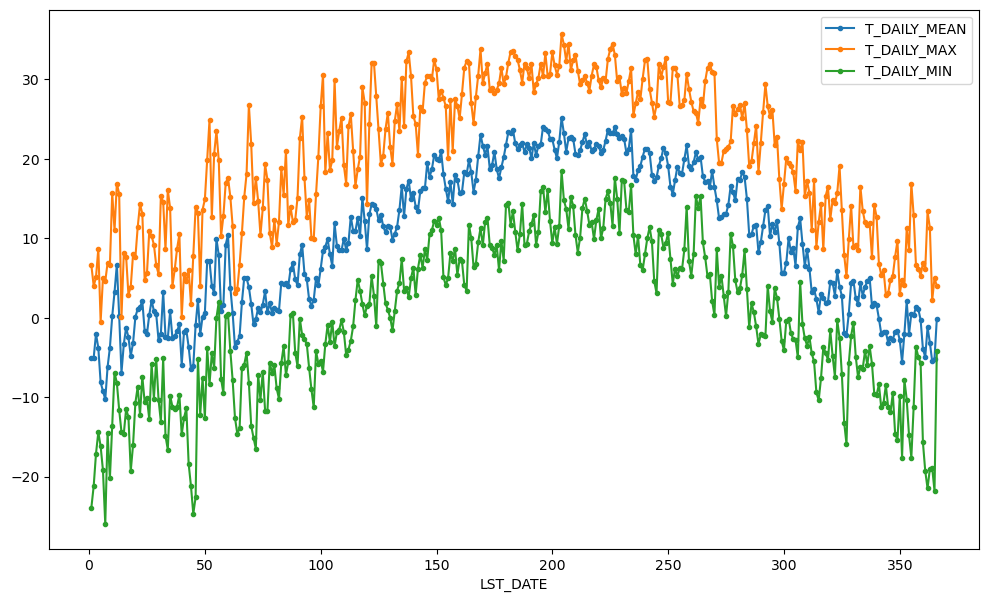

In [33]:
daily_T_climatology = df.groupby(df.index.dayofyear).aggregate({'T_DAILY_MEAN': 'mean',
                                                            'T_DAILY_MAX': 'max',
                                                            'T_DAILY_MIN': 'min'})
daily_T_climatology.plot(marker='.')

### Calculating anomalies

A common mode of analysis in climate science is to remove the climatology from a signal to focus only on the "anomaly" values. This can be accomplished with transformation.

First, let's first drop SUR_TEMP_DAILY_TYPE column as it's giving us troubles with arithmetic.

In [34]:
df = df.drop(columns='SUR_TEMP_DAILY_TYPE')
df

,WBANNO,CRX_VN,LONGITUDE,LATITUDE,T_DAILY_MAX,T_DAILY_MIN,T_DAILY_MEAN,T_DAILY_AVG,P_DAILY_CALC,SOLARAD_DAILY,...,SOIL_MOISTURE_10_DAILY,SOIL_MOISTURE_20_DAILY,SOIL_MOISTURE_50_DAILY,SOIL_MOISTURE_100_DAILY,SOIL_TEMP_5_DAILY,SOIL_TEMP_10_DAILY,SOIL_TEMP_20_DAILY,SOIL_TEMP_50_DAILY,SOIL_TEMP_100_DAILY,
LST_DATE,,,,,,,,,,,,,,,,,,,,,
2016-01-01,64756,2.422,-73.74,41.79,3.4,-0.5,1.5,1.3,0.0,1.69,...,0.233,0.204,0.155,0.147,4.2,4.4,5.1,6.0,7.6,NaN
2016-01-02,64756,2.422,-73.74,41.79,2.9,-3.6,-0.4,-0.3,0.0,6.25,...,0.227,0.199,0.152,0.144,2.8,3.1,4.2,5.7,7.4,NaN
2016-01-03,64756,2.422,-73.74,41.79,5.1,-1.8,1.6,1.1,0.0,5.69,...,0.223,0.196,0.151,0.141,2.6,2.8,3.8,5.2,7.2,NaN
2016-01-04,64756,2.422,-73.74,41.79,0.5,-14.4,-6.9,-7.5,0.0,9.17,...,0.220,0.194,0.148,0.139,1.7,2.1,3.4,4.9,6.9,NaN
2016-01-05,64756,2.422,-73.74,41.79,-5.2,-15.5,-10.3,-11.7,0.0,9.34,...,0.213,0.191,0.148,0.138,0.4,0.9,2.4,4.3,6.6,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-27,64756,2.622,-73.74,41.79,2.5,-2.1,0.2,0.3,0.0,7.50,...,0.275,0.248,0.191,0.192,1.3,1.4,1.9,3.2,4.7,NaN
2018-12-28,64756,2.622,-73.74,41.79,11.6,1.9,6.8,7.6,11.5,0.45,...,0.295,0.261,0.193,0.191,2.9,2.7,2.5,3.1,4.5,NaN
2018-12-29,64756,2.622,-73.74,41.79,11.3,-2.1,4.6,6.3,0.0,4.89,...,0.295,0.270,0.208,0.191,4.5,4.4,4.0,3.8,4.5,NaN


<Axes: xlabel='LST_DATE'>

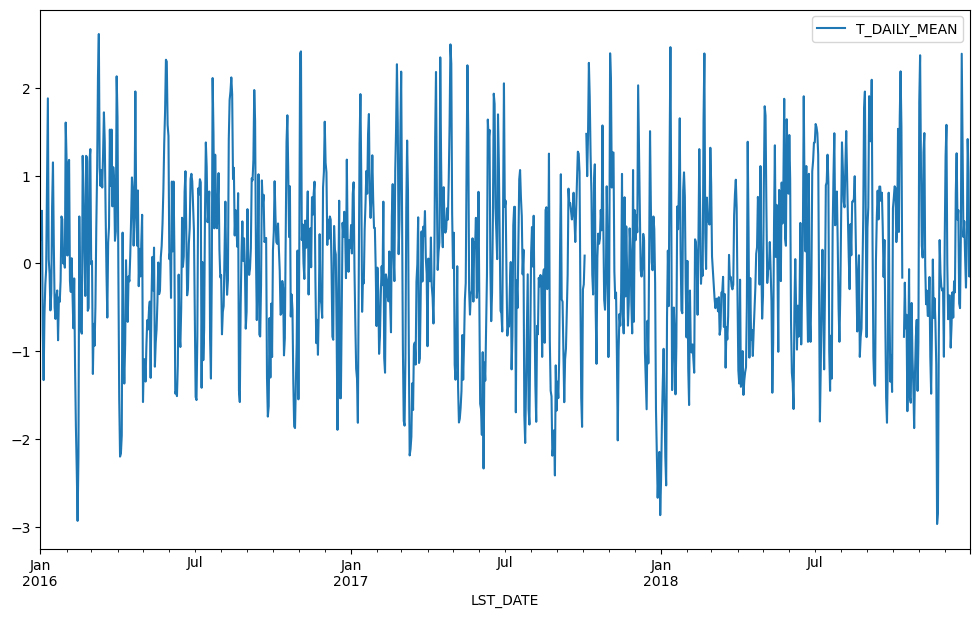

In [35]:
def standardize(x):
    return (x - x.mean())/x.std()

anomaly = df.groupby(df.index.month).transform(standardize) # calculate standardized anomaly
anomaly.plot(y='T_DAILY_MEAN')

An alternative would be to use a lambda function, which is usually used to create small, anonymous functions on the fly.

<Axes: xlabel='LST_DATE'>

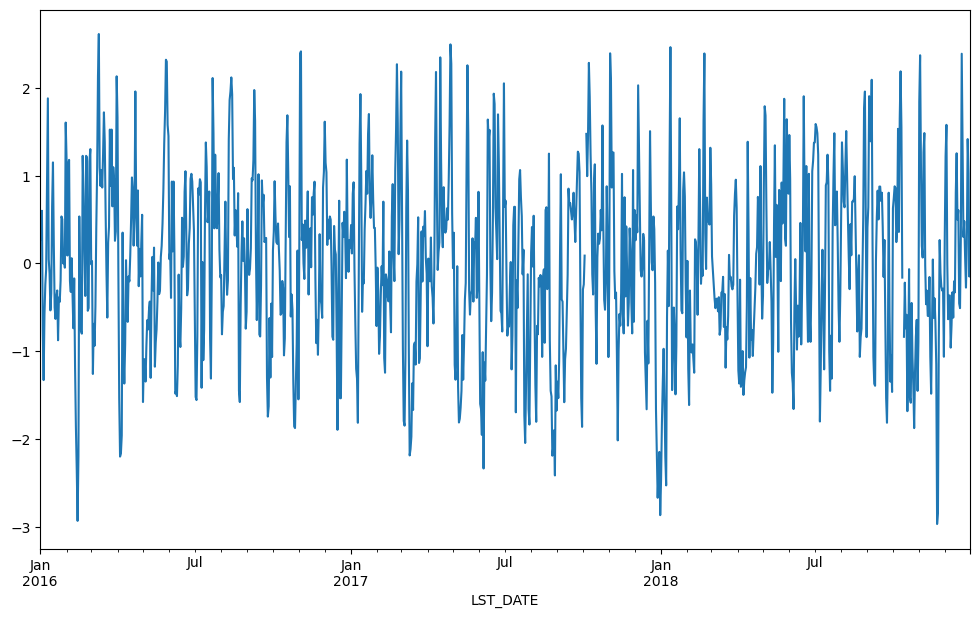

In [36]:
anomaly = df.T_DAILY_MEAN.groupby(df.index.month).transform(lambda x: (x-x.mean())/x.std()) 
anomaly.plot(y='T_DAILY_MEAN')

### Resampling

Another common operation is to change the resolution of a dataset by resampling in time. Pandas exposes this through the [resample](http://pandas.pydata.org/pandas-docs/stable/timeseries.html#resampling) function. The resample periods are specified using pandas [offset index](http://pandas.pydata.org/pandas-docs/stable/timeseries.html#offset-aliases) syntax.

Below we resample the dataset by taking the mean over each month.

/tmp/ipykernel_237/3535943585.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.resample('M').mean().plot(y='T_DAILY_MEAN', marker='o')


<Axes: xlabel='LST_DATE'>

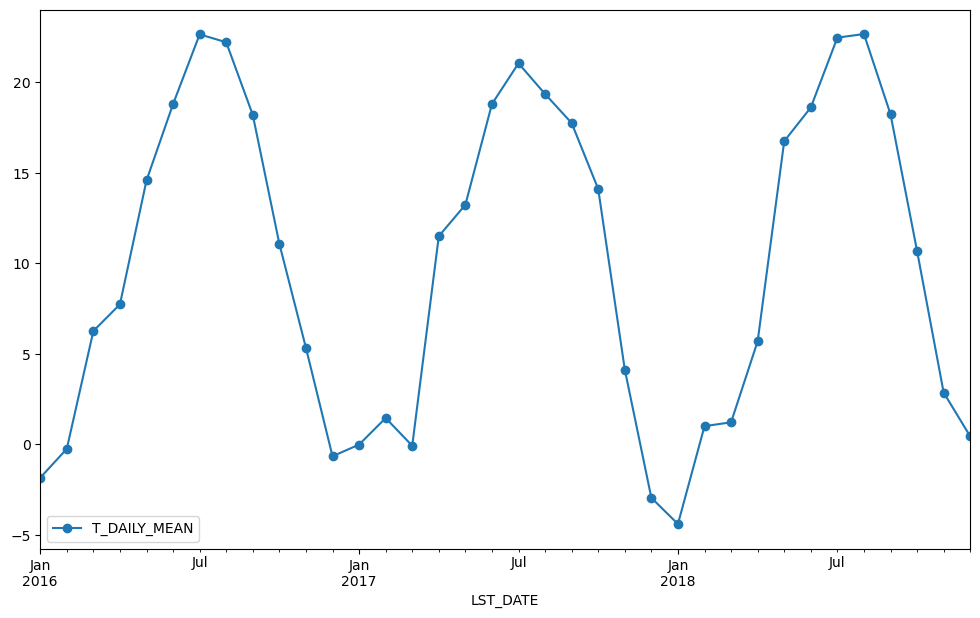

In [15]:
df.resample('M').mean().plot(y='T_DAILY_MEAN', marker='o')

Just like with `groupby`, we can apply any aggregation function to our `resample` operation.

/tmp/ipykernel_237/2688213887.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.resample('M').max().plot(y='T_DAILY_MAX', marker='o')


<Axes: xlabel='LST_DATE'>

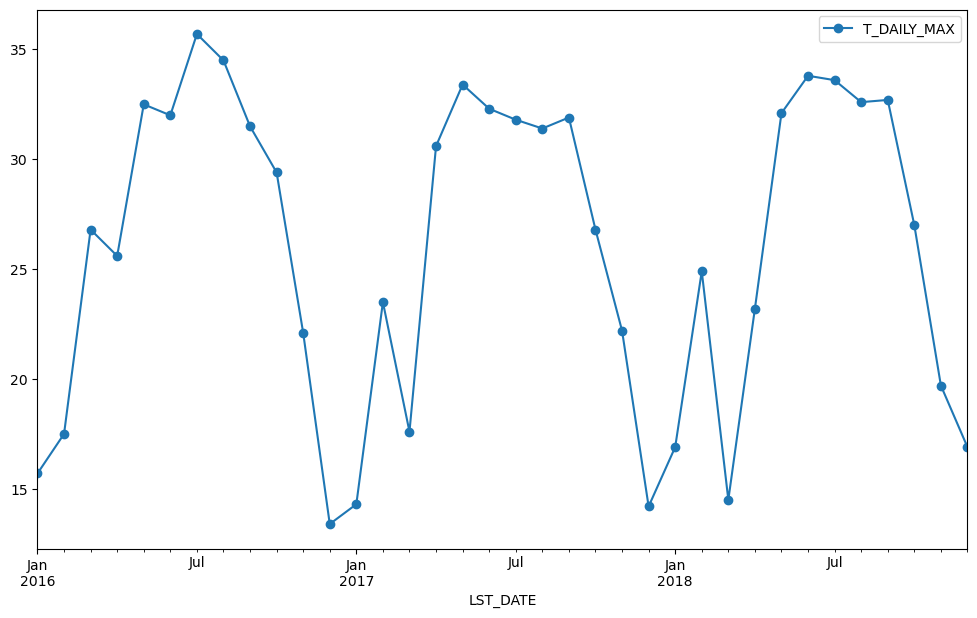

In [16]:
df.resample('M').max().plot(y='T_DAILY_MAX', marker='o')

### Rolling Operations

The final category of operations applies to "rolling windows". (See [rolling](https://pandas.pydata.org/pandas-docs/stable/generated/pandas.DataFrame.rolling.html) documentation.) We specify a function to apply over a moving window along the index. We specify the size of the window and, optionally, the weights. We also use the keyword `centered` to tell pandas whether to center the operation around the midpoint of the window.

<Axes: xlabel='LST_DATE'>

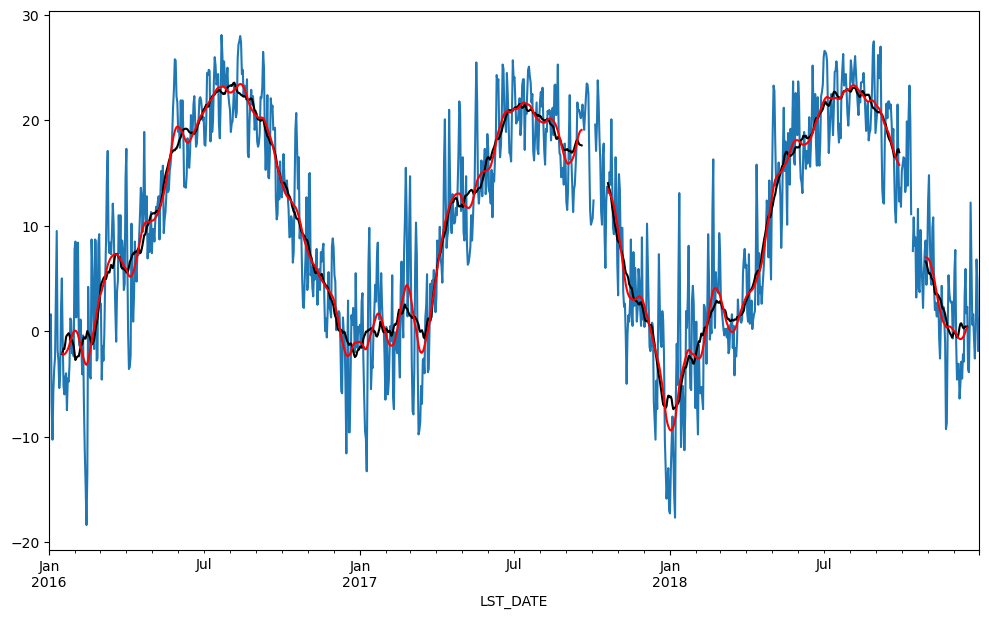

In [17]:
df.T_DAILY_MEAN.plot()
df.rolling(30, center=True).T_DAILY_MEAN.mean().plot(color='k')
df.rolling(30, center=True, win_type='triang').T_DAILY_MEAN.mean().plot(color='r')
# win_type: specifies the type of window to use for the rolling calculation
# a triangular window gives more weight to the central values in the window and less weight to the values at the edges